In [5]:
import zipfile
import pandas as pd

# 1. Check karo andar kya hai (tum already kar chuke ho)
with zipfile.ZipFile('googleplaystore.csv.zip') as z:
    print(z.namelist())  # ['googleplaystore.csv'] -> sirf 1 file hai

# 2. Sahi code - sirf apps wali file padho
with zipfile.ZipFile('googleplaystore.csv.zip') as z:
    with z.open('googleplaystore.csv') as f:
        apps = pd.read_csv(f)

print("Ho gaya! Apps:", apps.shape)
print(apps.head())

['googleplaystore.csv']
Ho gaya! Apps: (10841, 13)
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2

In [7]:
import zipfile

# Zip ko extract karke csv banao
with zipfile.ZipFile('googleplaystore.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()  # Isse same folder me googleplaystore.csv ban jayegi

print("Done! Ab folder me googleplaystore.csv ban gayi hai")

Done! Ab folder me googleplaystore.csv ban gayi hai


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File to ab aa gayi hai
apps = pd.read_csv('googleplaystore.csv')

# --- FINAL CLEANING (ye wala chalega) ---
apps['Installs'] = apps['Installs'].astype(str).str.replace(',', '').str.replace('+', '').str.replace('Free', '0')
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

apps['Price'] = apps['Price'].astype(str).str.replace('$', '').str.strip()
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')  # ye fix hai

apps['Size'] = apps['Size'].apply(lambda x: float(str(x).replace('M','')) if 'M' in str(x) else None)

apps.dropna(subset=['Rating'], inplace=True)
apps.drop_duplicates(inplace=True)

print("Cleaning Done! Shape:", apps.shape)
apps.head()

Cleaning Done! Shape: (8893, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


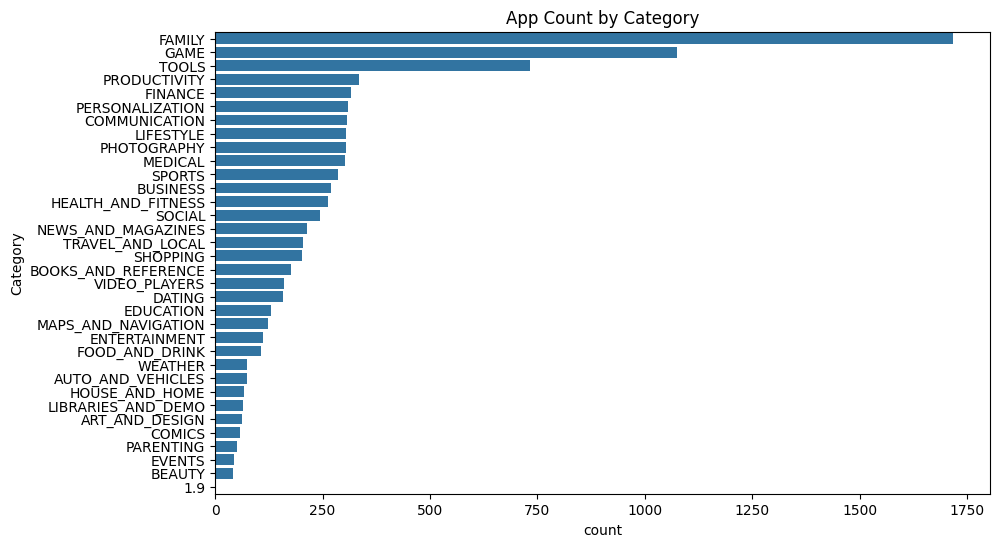

Category
FAMILY                 1718
GAME                   1074
TOOLS                   734
PRODUCTIVITY            334
FINANCE                 317
PERSONALIZATION         310
COMMUNICATION           307
LIFESTYLE               305
PHOTOGRAPHY             304
MEDICAL                 302
SPORTS                  286
BUSINESS                270
HEALTH_AND_FITNESS      262
SOCIAL                  244
NEWS_AND_MAGAZINES      214
TRAVEL_AND_LOCAL        205
SHOPPING                202
BOOKS_AND_REFERENCE     177
VIDEO_PLAYERS           160
DATING                  159
EDUCATION               129
MAPS_AND_NAVIGATION     124
ENTERTAINMENT           111
FOOD_AND_DRINK          106
WEATHER                  75
AUTO_AND_VEHICLES        73
HOUSE_AND_HOME           68
LIBRARIES_AND_DEMO       65
ART_AND_DESIGN           62
COMICS                   58
PARENTING                50
EVENTS                   45
BEAUTY                   42
1.9                       1
Name: count, dtype: int64


In [10]:
# Kaunsi category me sabse zyada apps hai?
plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=apps, order=apps['Category'].value_counts().index)
plt.title('App Count by Category')
plt.show()

print(apps['Category'].value_counts())

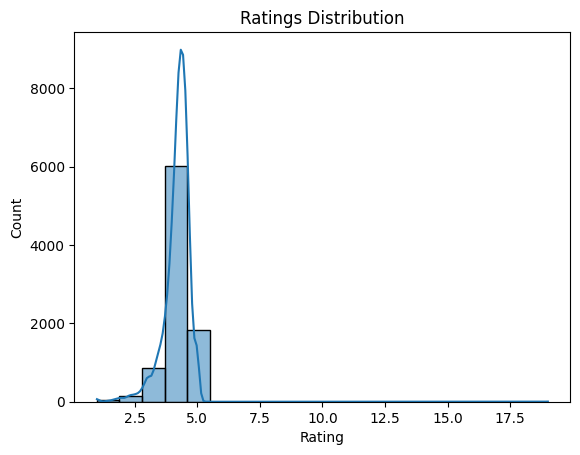

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.375969
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.347458
PERSONALIZATION         4.333871
PARENTING               4.300000
GAME                    4.281285
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.261450
SOCIAL                  4.254918
SHOPPING                4.251485
WEATHER                 4.244000
SPORTS                  4.225175
PRODUCTIVITY            4.201796
FAMILY                  4.191153
AUTO_AND_VEHICLES       4.190411
PHOTOGRAPHY             4.182895
MEDICAL                 4.182450
LIBRARIES_AND_DEMO      4.178462
HOUSE_AND_HOME          4.164706
FOOD_AND_DRINK          4.164151
COMICS                  4.155172
COMMUNICATION           4.151466
ENTERTAINMENT           4.136036
NEWS_AND_MAGAZINES      4.128505
FINANCE                 4.127445
BUSINESS                4.102593
LIFESTYLE               4.096066
TRAVEL_AND_LOCAL        4.094146
V

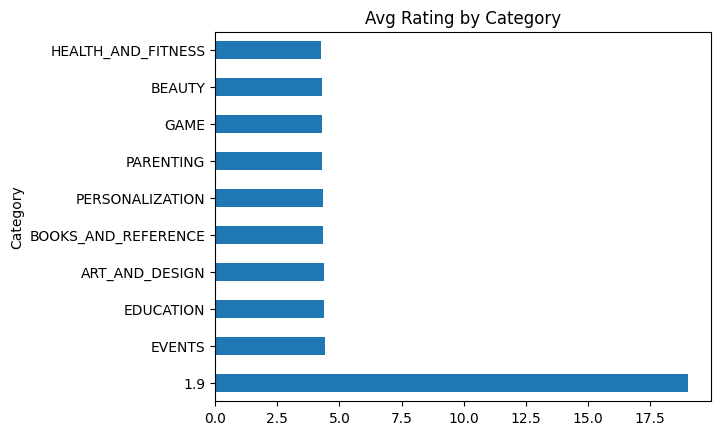

In [11]:
# Ratings ka distribution
sns.histplot(apps['Rating'], bins=20, kde=True)
plt.title('Ratings Distribution')
plt.show()

# Category wise average rating
avg = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print(avg)
avg.head(10).plot(kind='barh')
plt.title('Avg Rating by Category')
plt.show()

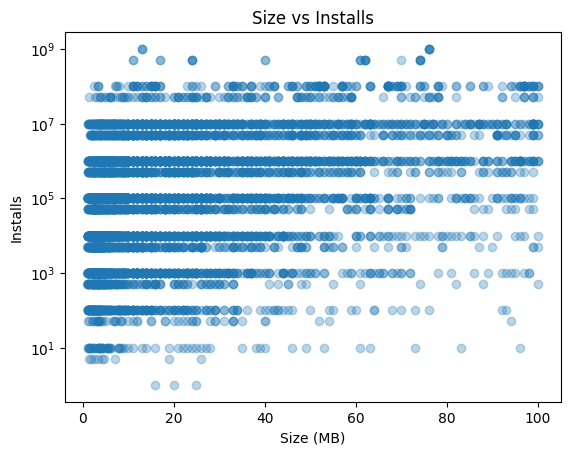

Correlation: 0.16440624957678698


In [12]:
# Kya bade size wale apps kam install hote hai?
plt.scatter(apps['Size'], apps['Installs'], alpha=0.3)
plt.yscale('log')
plt.xlabel('Size (MB)')
plt.ylabel('Installs')
plt.title('Size vs Installs')
plt.show()

print("Correlation:", apps['Size'].corr(apps['Installs']))

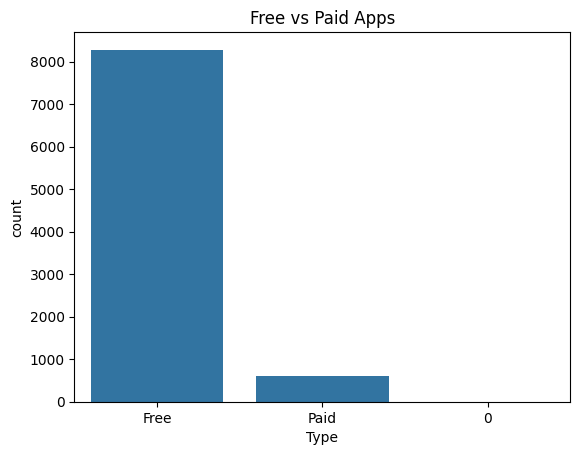

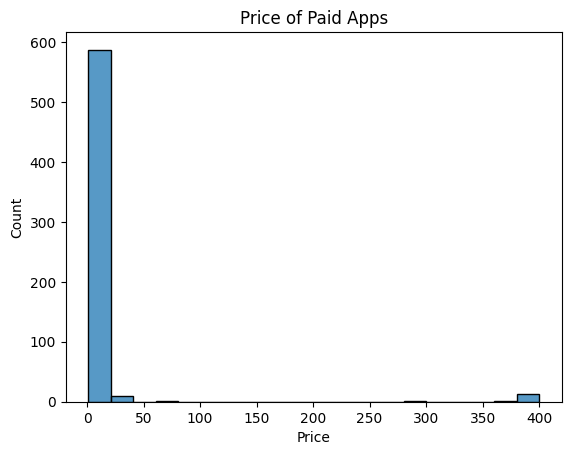

Category
FAMILY         1.857743e+08
LIFESTYLE      5.758394e+07
GAME           4.098684e+07
FINANCE        2.572664e+07
PHOTOGRAPHY    8.941050e+06
Name: Revenue, dtype: float64


In [13]:
# Free vs Paid
sns.countplot(x='Type', data=apps)
plt.title('Free vs Paid Apps')
plt.show()

# Paid apps ka price distribution
paid = apps[apps['Type']=='Paid']
sns.histplot(paid['Price'], bins=20)
plt.title('Price of Paid Apps')
plt.show()

# Revenue estimate
apps['Revenue'] = apps['Price'] * apps['Installs']
print(apps.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head())

In [15]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.8 MB/s eta 0:00:00


In [17]:
import plotly.express as px
fig = px.scatter(apps, x='Size', y='Rating', color='Category', size='Installs', hover_data=['App'])
fig.show()